**ADDESTRAMENTO ENCODER**

SETUP

In [1]:
import digitalhub as dh
import pandas as pd
import matplotlib.pyplot as plt

NOME_PROGETTO = "floods"
project = dh.get_project(NOME_PROGETTO)
print(f"Progetto: {project.name}")

Progetto: floods


TRAINING

In [2]:
encoders_train_func = project.new_function(
    name="encoders_train-job-v44",
    kind="python",
    python_version="PYTHON3_10",
    code_src="Encoders/", 
    handler="pretrain_encoders", 
    base_image="pytorch/pytorch:2.1.2-cuda11.8-cudnn8-runtime",
    requirements=["pandas==2.3.3", "numpy==1.26.4", "rasterio==1.4.4", "tqdm==4.70.0", "tifffile==2024.8.30"]
)

build = encoders_train_func.run("build", wait=True)
print(f"BUILD: {build.status.state}")



2026-08-11 09:31:59,711 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 02c00393d83f4b518a8a2045ba22a188 to finish...
2026-08-11 09:32:04,723 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 02c00393d83f4b518a8a2045ba22a188 to finish...
2026-08-11 09:32:09,739 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 02c00393d83f4b518a8a2045ba22a188 to finish...
2026-08-11 09:32:14,758 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 02c00393d83f4b518a8a2045ba22a188 to finish...
2026-08-11 09:32:19,774 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 02c00393d83f4b518a8a2045ba22a188 to finish...
2026-08-11 09:32:24,790 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 02c00393d83f4b518a8a2045ba22a188 to finish...
2026-08-11 09:32:29,807 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 02c00393d83f4b518a8a2045ba22a188 to finish...
2026-08-11 09

BUILD: COMPLETED


In [3]:
# setup ambiente
volumi = [
    {
        "volume_type": "ephemeral",
        "name": "volume-spazio-dati",
        "mount_path": "/data",      
        "spec": {"size": "200Gi"}   
    }
]

parametri = {
    "epochs": 200, 
    "batch_size": 16, 
    "lr": 1e-4, 
    "weight_decay": 1e-4,      
    "patch_size": 256, 
    "n_images1": 4, "n_channels1": 2,                       # sar
    "n_images2": 4, "n_channels2": 10,                      # ottiche               
    "mamba": False, 
    "workers": 0
}

print(f"PARAMETRI: {parametri}")

run_train_encoders = encoders_train_func.run(
    action="job", 
    parameters=parametri, 
    volumes=volumi, 
    profile="1xV100",
    # local_execution= True,                                # 1x = 1 gpu
    wait=True
)

print(f"STATO FINALE: {run_train_encoders.status.state}")
print(run_train_encoders.logs())

2026-08-11 09:34:19,321 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run dd26124641d14dc09d94ef343c19e0a1 to finish...


PARAMETRI: {'epochs': 200, 'batch_size': 16, 'lr': 0.0001, 'weight_decay': 0.0001, 'patch_size': 256, 'n_images1': 4, 'n_channels1': 2, 'n_images2': 4, 'n_channels2': 10, 'mamba': False, 'workers': 0}


2026-08-11 09:34:24,331 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run dd26124641d14dc09d94ef343c19e0a1 to finish...
2026-08-11 09:34:29,453 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run dd26124641d14dc09d94ef343c19e0a1 to finish...
2026-08-11 09:34:34,470 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run dd26124641d14dc09d94ef343c19e0a1 to finish...
2026-08-11 09:34:39,486 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run dd26124641d14dc09d94ef343c19e0a1 to finish...
2026-08-11 09:34:44,501 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run dd26124641d14dc09d94ef343c19e0a1 to finish...
2026-08-11 09:34:49,521 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run dd26124641d14dc09d94ef343c19e0a1 to finish...
2026-08-11 09:34:54,641 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run dd26124641d14dc09d94ef343c19e0a1 to finish...
2026-08-11 09

STATO FINALE: COMPLETED
[{'kind': 'log', 'metadata': {'project': 'floods', 'name': 'e853e00a5c174d5cb31e73ef8f67c41c', 'version': 'grand-eagle', 'created': '2026-08-11T09:34:54.936Z', 'updated': '2026-08-11T11:31:03.123Z', 'created_by': 'mbarborini@fbk.eu', 'updated_by': 'mbarborini@fbk.eu'}, 'spec': {'run': 'dd26124641d14dc09d94ef343c19e0a1', 'timestamp': 1786440894929}, 'status': {'state': 'CREATED', 'container': 'init-container-dd26124641d14dc09d94ef343c19e0a1', 'pod': 'j-pythonjob-dd26124641d14dc09d94ef343c19e0a1-86mgj', 'namespace': 'rsde-platform', 'containerId': '8b61ba64fd27a4ca80bbf005f713e86f4c3488162aa3d222947f64bb4333fb6f'}, 'user': 'mbarborini@fbk.eu', 'project': 'floods', 'name': 'e853e00a5c174d5cb31e73ef8f67c41c', 'id': 'e853e00a5c174d5cb31e73ef8f67c41c', 'key': 'store://floods/log/log/e853e00a5c174d5cb31e73ef8f67c41c:e853e00a5c174d5cb31e73ef8f67c41c'}, {'kind': 'log', 'metadata': {'project': 'floods', 'name': '844e21951e194844a61d0046355d6d13', 'version': 'alert-otter',

RISULTATI

SALVATAGGIO METRICHE


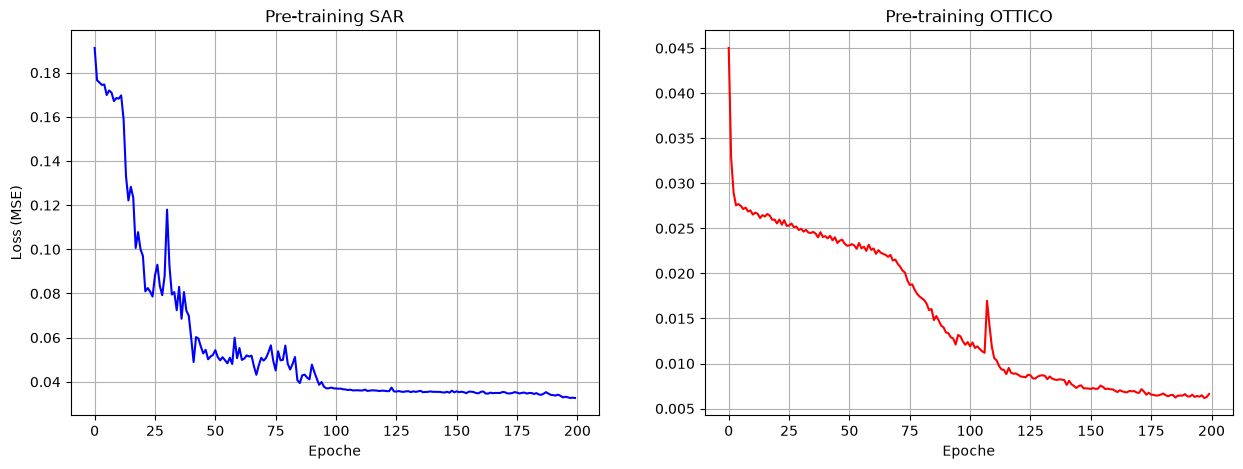

In [4]:
# salvataggio log
print("SALVATAGGIO METRICHE")

path_s1 = project.get_artifact("metrics-s1").download(overwrite=True)
path_s2 = project.get_artifact("metrics-s2").download(overwrite=True)

# risultati grafici
df_s1 = pd.read_csv(path_s1)
df_s2 = pd.read_csv(path_s2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# sar
ax1.plot(df_s1['epoch'], df_s1['train_loss'], color='blue', label='Train Loss')
ax1.set_title('Pre-training SAR')
ax1.set_xlabel('Epoche')
ax1.set_ylabel('Loss (MSE)')
ax1.grid(True)

# ottico
ax2.plot(df_s2['epoch'], df_s2['train_loss'], color='red', label='Train Loss')
ax2.set_title('Pre-training OTTICO')
ax2.set_xlabel('Epoche')
ax2.grid(True)

plt.show()
